<a href="https://colab.research.google.com/github/Manasa23BEIS123/AIML-12-Week-Program/blob/feat%2Faiml-W2-Manasa/W2D3_Handling_Imbalanced_Data_SMOTE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# W2D3: Handling Imbalanced Data — SMOTE

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Create an imbalanced binary classification dataset

from sklearn.datasets import make_classification

X, y = make_classification(
    n_samples=1000,
    n_features=6,
    n_informative=4,
    n_redundant=0,
    n_classes=2,
    weights=[0.90, 0.10],
    random_state=42
)

print("Dataset shape:", X.shape)
print("\nClass distribution:")
print(pd.Series(y).value_counts())

Dataset shape: (1000, 6)

Class distribution:
0    895
1    105
Name: count, dtype: int64


Class Distribution:
0    895
1    105
Name: count, dtype: int64


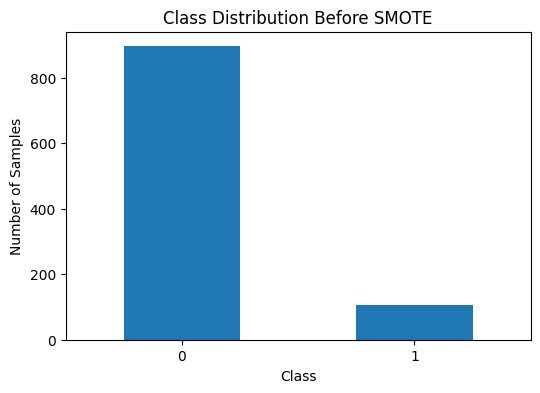

In [3]:
# Check and visualize class distribution

class_counts = pd.Series(y).value_counts().sort_index()

print("Class Distribution:")
print(class_counts)

plt.figure(figsize=(6, 4))
class_counts.plot(kind="bar")
plt.title("Class Distribution Before SMOTE")
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)
plt.show()

In [4]:
# Split the dataset into training and testing sets
# Stratify keeps the same class ratio in both sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining class distribution:")
print(pd.Series(y_train).value_counts())

print("\nTesting class distribution:")
print(pd.Series(y_test).value_counts())

Training set: (800, 6)
Testing set: (200, 6)

Training class distribution:
0    716
1     84
Name: count, dtype: int64

Testing class distribution:
0    179
1     21
Name: count, dtype: int64


In [5]:
!pip install -q imbalanced-learn

In [7]:
# Apply SMOTE only to the training data

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("Before SMOTE:")
print(pd.Series(y_train).value_counts())

print("\nAfter SMOTE:")
print(pd.Series(y_train_smote).value_counts())

Before SMOTE:
0    716
1     84
Name: count, dtype: int64

After SMOTE:
0    716
1    716
Name: count, dtype: int64


   Before SMOTE  After SMOTE
0           716          716
1            84          716


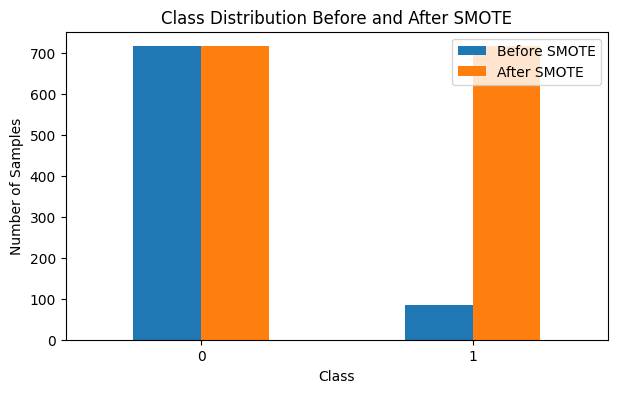

In [8]:
# Compare class distribution before and after SMOTE

before_smote = pd.Series(y_train).value_counts().sort_index()
after_smote = pd.Series(y_train_smote).value_counts().sort_index()

comparison = pd.DataFrame({
    "Before SMOTE": before_smote,
    "After SMOTE": after_smote
})

print(comparison)

comparison.plot(kind="bar", figsize=(7, 4))
plt.title("Class Distribution Before and After SMOTE")
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)
plt.show()

In [9]:
# Train Logistic Regression on the SMOTE-balanced training data

model = LogisticRegression(random_state=42, max_iter=1000)

model.fit(X_train_smote, y_train_smote)

# Predict on the original test data
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.71

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.73      0.82       179
           1       0.20      0.57      0.29        21

    accuracy                           0.71       200
   macro avg       0.57      0.65      0.56       200
weighted avg       0.86      0.71      0.76       200



Confusion Matrix:
[[130  49]
 [  9  12]]


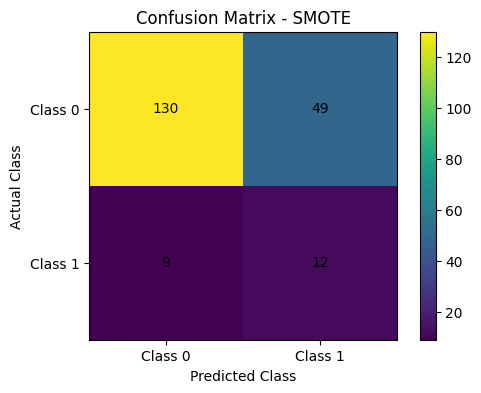

In [10]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(6, 4))
plt.imshow(cm)
plt.title("Confusion Matrix - SMOTE")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.colorbar()

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xticks([0, 1], ["Class 0", "Class 1"])
plt.yticks([0, 1], ["Class 0", "Class 1"])
plt.show()

In [11]:
# Evaluate the SMOTE model

print("Final Model Evaluation")
print("-" * 30)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Final Model Evaluation
------------------------------
Accuracy: 0.71

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.73      0.82       179
           1       0.20      0.57      0.29        21

    accuracy                           0.71       200
   macro avg       0.57      0.65      0.56       200
weighted avg       0.86      0.71      0.76       200


Confusion Matrix:
[[130  49]
 [  9  12]]


In [12]:
# Basic validation checks

assert len(X_train_smote) == len(y_train_smote)
assert pd.Series(y_train_smote).value_counts().nunique() == 1
assert len(X_test) == len(y_test)

print("All validation checks passed!")
print("SMOTE successfully balanced the training data.")

All validation checks passed!
SMOTE successfully balanced the training data.
